In [250]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [251]:
from sklearn.datasets import load_iris

In [252]:
iris=load_iris()

In [253]:
# Create DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add target column
df['target'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [254]:
X=df.drop('target',axis=1)

In [255]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [256]:
y=df['target']
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [257]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [258]:
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier()

In [259]:
classifier.fit(X_train,y_train)

DecisionTreeClassifier()

In [260]:
y_pred=classifier.predict(X_test)

In [261]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

ACCURACY: 96.66666666666667 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



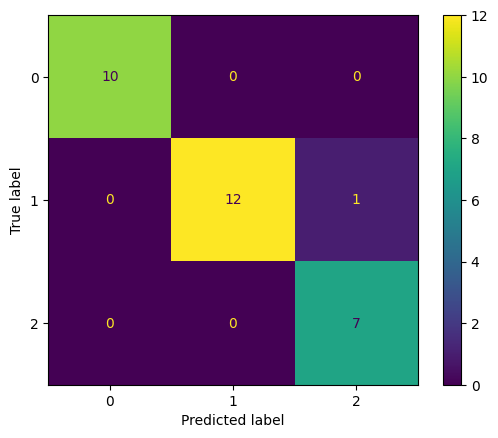

In [262]:
print("ACCURACY:",accuracy_score(y_test,y_pred)*100,"%")
print(classification_report(y_test,y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred))
disp.plot()

[Text(0.3076923076923077, 0.9285714285714286, 'x[2] <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.38461538461538464, 0.5, 'x[1] <= 2.65\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0,

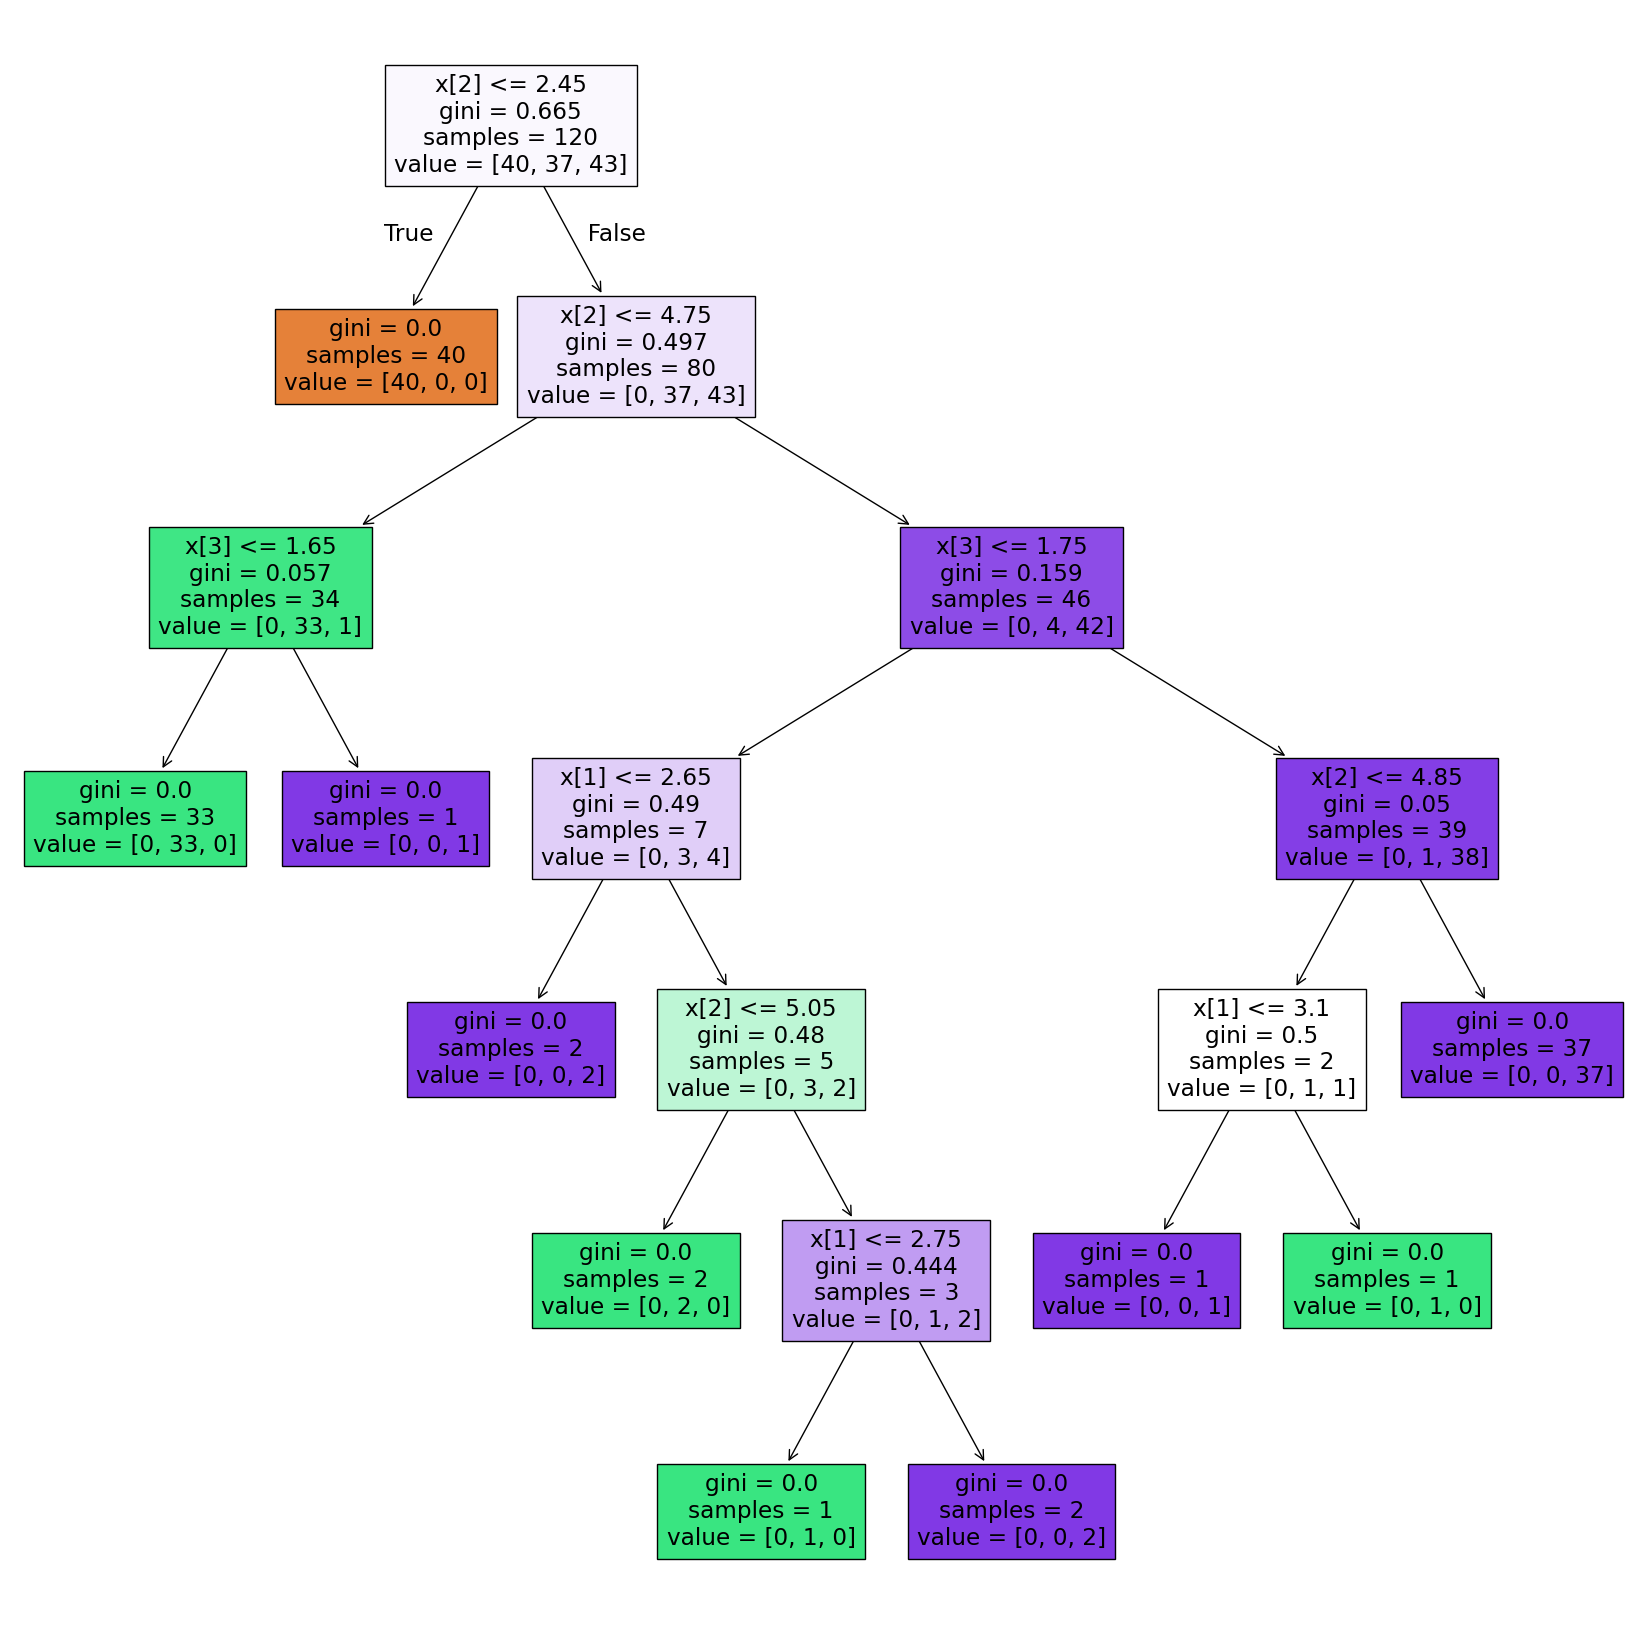

In [263]:
from sklearn import tree
plt.figure(figsize=(21,21))
tree.plot_tree(classifier,filled=True)

##  POST PRUNING

AFTER LEAF NODE 2 THERE IS NO REQUIREMENT OF MORE NODES. WE CAN SET OUR MAX DEPTH TO 2

In [264]:
classifier1=DecisionTreeClassifier(max_depth=2)
classifier1.fit(X_train,y_train)
y_pred1=classifier1.predict(X_test)


ACCURACY: 93.33333333333333 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



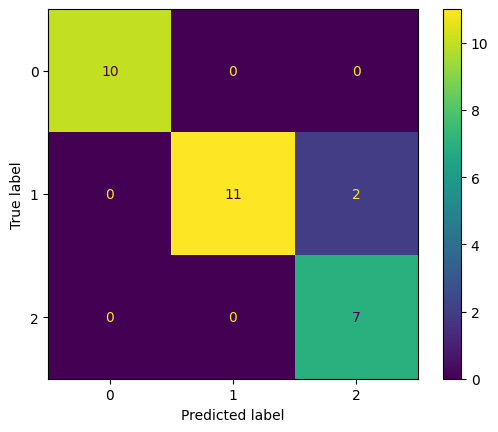

In [265]:
print("ACCURACY:",accuracy_score(y_test,y_pred1)*100,"%")
print(classification_report(y_test,y_pred1))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred1))
disp.plot()

## PRE-PRUNING

In [266]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [267]:
cv=StratifiedKFold()

In [268]:
params={'criterion':['gini', 'entropy', 'log_loss'],
        'splitter':['best', 'random'],
        'max_features':['auto','sqrt','log2'],
        'max_depth': [1,2,3,4,5],     
        }

In [269]:
grid=GridSearchCV(DecisionTreeClassifier(),param_grid=params,cv=cv,refit=True,verbose=3,n_jobs=-1)

In [270]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


c:\DS and ML\venv\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
95 fits failed with the following error:
Traceback (most recent call last):
  File "c:\DS and ML\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\DS and ML\venv\lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\DS and ML\venv\lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "c:\DS and ML\venv\lib\site-packages\sklearn\utils\_param_validation.p

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             verbose=3)

In [271]:
y_pred2=grid.predict(X_test)


In [272]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'random'}

ACCURACY: 90.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.77      0.87        13
           2       0.70      1.00      0.82         7

    accuracy                           0.90        30
   macro avg       0.90      0.92      0.90        30
weighted avg       0.93      0.90      0.90        30



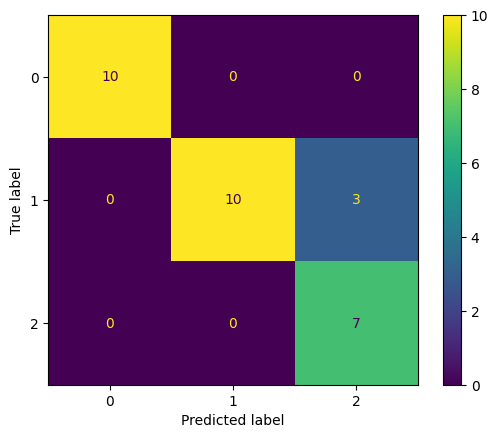

In [273]:
print("ACCURACY:",accuracy_score(y_test,y_pred2)*100,"%")
print(classification_report(y_test,y_pred2))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred2))
disp.plot()

[Text(0.4444444444444444, 0.9, 'x[2] <= 1.874\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.3333333333333333, 0.7, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'x[2] <= 4.633\ngini = 0.509\nsamples = 81\nvalue = [1, 37, 43]'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'x[3] <= 1.528\ngini = 0.127\nsamples = 30\nvalue = [1, 28, 1]'),
 Text(0.2222222222222222, 0.3, 'x[2] <= 3.193\ngini = 0.067\nsamples = 29\nvalue = [1, 28, 0]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [1, 1, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 27\nvalue = [0, 27, 0]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.7777777777777778, 0.5, 'x[3] <= 1.879\ngini = 0.291\nsamples = 51\nvalue = [0, 9, 42]'),
 Text(0.6666666666666666, 0.3, 'x[0] <= 7.065\ngini = 0.476\nsamples = 23\nvalue = [0, 9, 14]'),
 Text(0.5555555555555556, 0

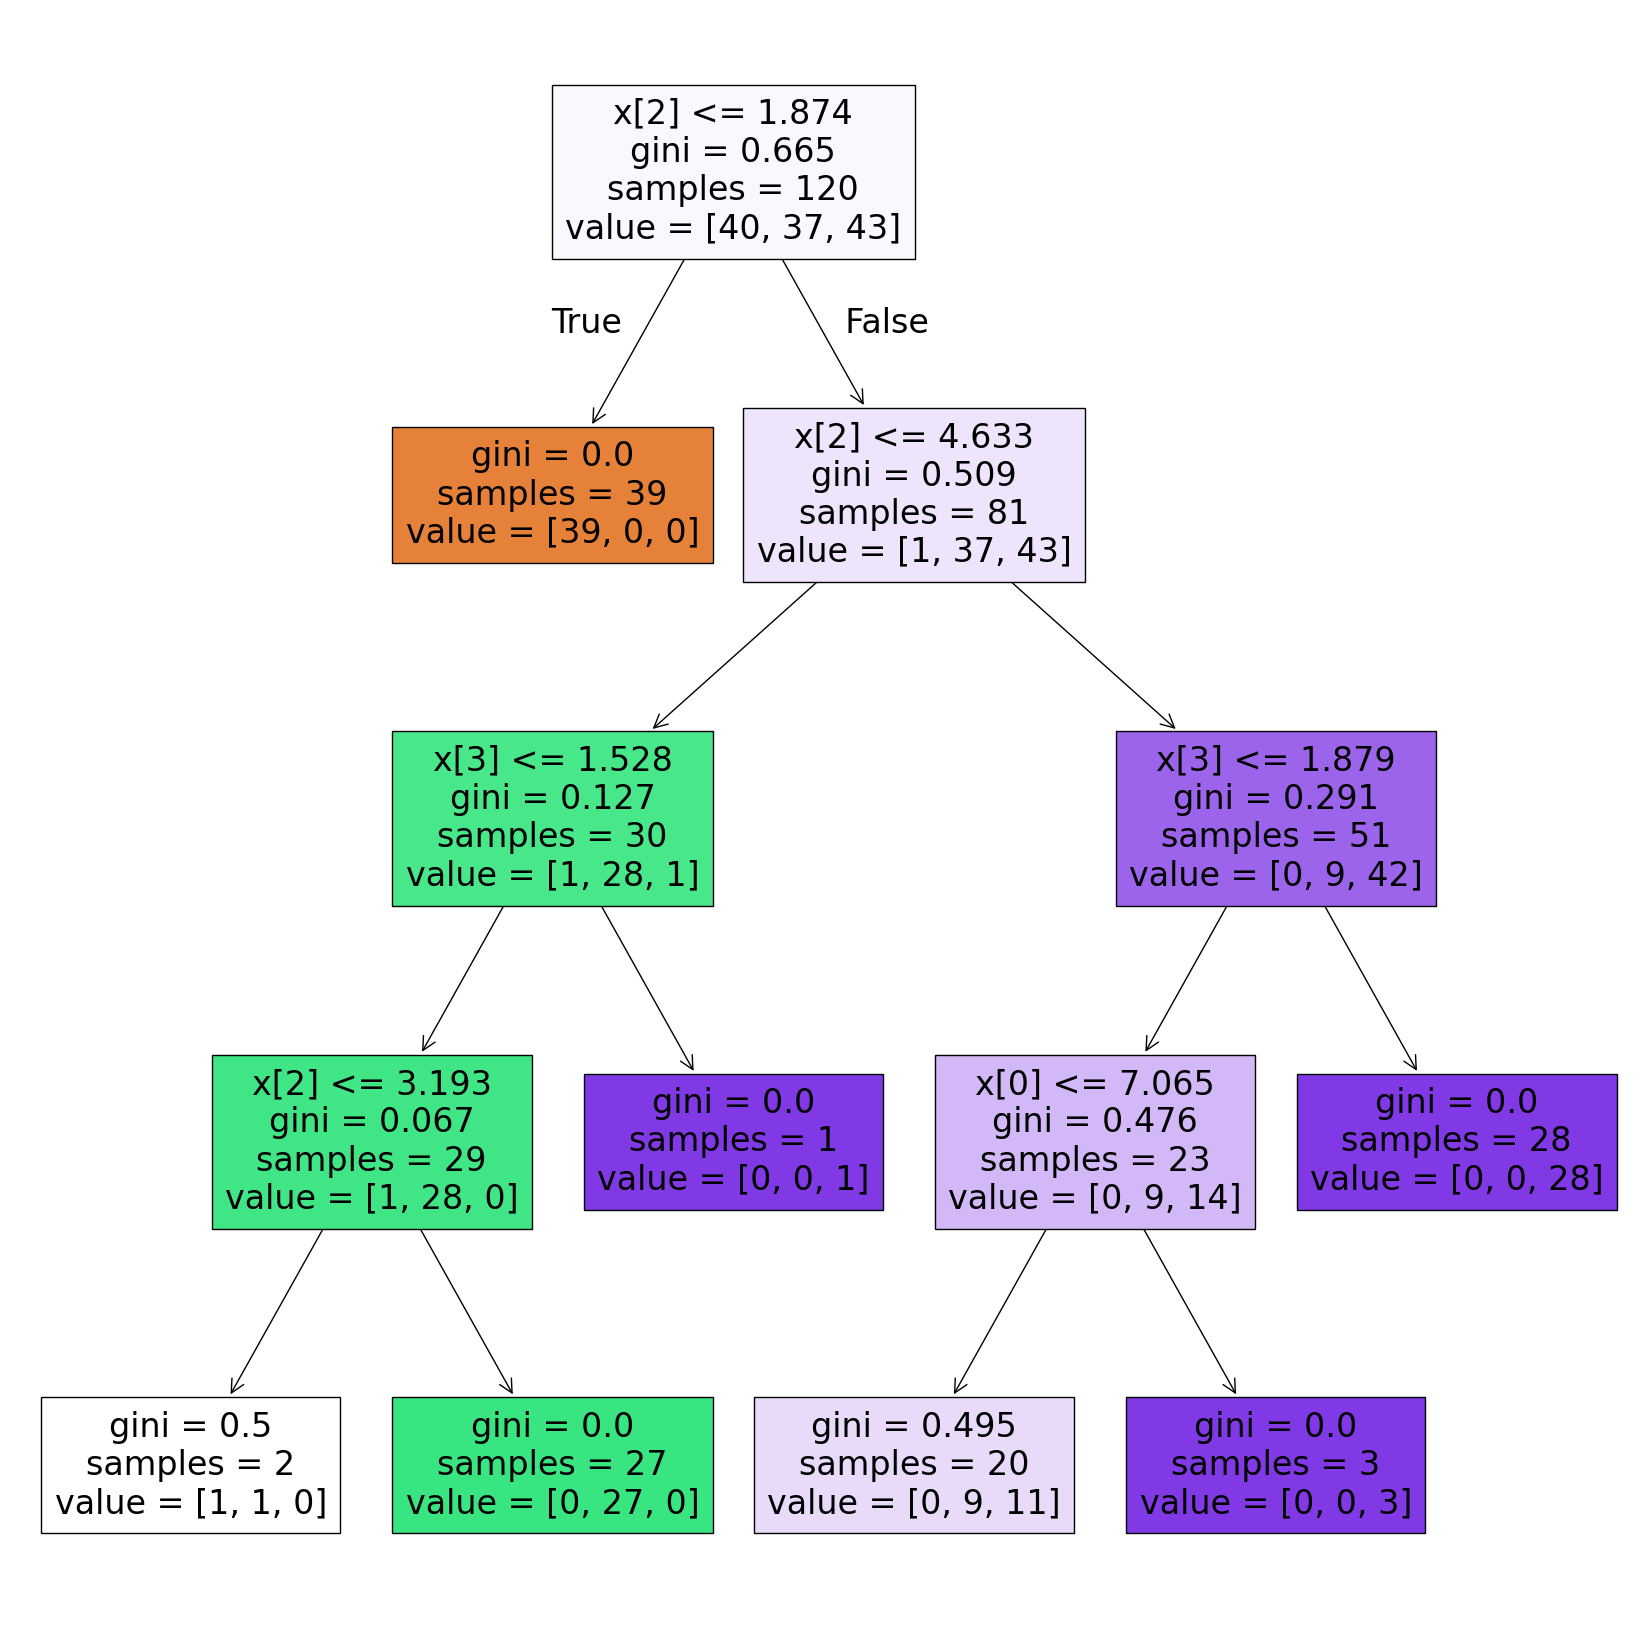

In [274]:
from sklearn import tree
plt.figure(figsize=(21,21))
tree.plot_tree(grid.best_estimator_,filled=True)